## Scaling relations


If you had to compute adsorption energies for every intermediate on every candidate catalyst, high-throughput screening would be prohibitively expensive. Scaling relations make screening tractable by revealing that the adsorption energies of different intermediates are not independent: across a wide range of metals, ΔGOOH tracks ΔGOH with a slope near 1 and an offset of about 3.2 eV, and ΔGO tracks ΔGOH with a slope near 2 and an offset of about 0.5 eV. These correlations mean that a single descriptor, typically ΔGOH, is enough to estimate the full energy landscape for a catalyst family.

The slope α follows from electron counting at the active site: OOH and OH both use one surface-bonding electron, so their energies shift together (α ≈ 1), while O requires two surface-bonding electrons compared to OH's one, giving α ≈ 2. The intercept β comes from bond energies that are independent of the catalyst: for OOH vs OH, β reflects the H₂/H₂O reference thermochemistry plus the cost of converting an O=O double bond to an O-O peroxide single bond; for O vs OH, β reflects the exchange of single and double bonds between the site and oxygen during the 2·OH → H₂O + O* + * step.

This notebook computes adsorption energies for O, OH, and OOH on seven FCC(111) metal surfaces using the UMA machine-learning potential, fits linear scaling relations to the results with scipy.stats.linregress, plots the two correlations on a shared axis with metal labels, and then derives α and β from first principles to show why these numbers have the values they do.

In [1]:
%%capture
!pip install fairchem-core --upgrade
!pip install ase

The UMA model is distributed under the FAIR Chemistry License by Meta, available at https://huggingface.co/facebook/UMA/blob/main/LICENSE. By running this notebook you agree to its terms. To use the model in your own environment, go to Hugging Face (huggingface.co), create an account, generate an access token under Settings > Access Tokens, and download the model via the fairchem API. Since tokens are personal and should not be shared, in this notebook we provide the model file via a direct Google Drive link instead.

In [2]:
!gdown 1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX -O uma-s-1p1.pt

Downloading...
From (original): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX
From (redirected): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX&confirm=t&uuid=ad623203-50a8-4583-8f7b-3ff5c915abf3
To: /content/uma-s-1p1.pt
100% 1.17G/1.17G [00:19<00:00, 59.7MB/s]


In [3]:
from ase import Atoms
from ase.build import fcc111, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.optimize import BFGS

from fairchem.core import FAIRChemCalculator
from fairchem.core import pretrained_mlip

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

Adjust the graphical settings

In [4]:
l = 8.25 / 2.54 ##-inches
plt.rc('figure', figsize=(l, l)) ##-figure size
plt.rc('figure', dpi=100) ##-figure dpi
plt.rc('lines', linewidth=2) ##-linewidth
plt.rc('font', size=10) ##-fontsize of the text
plt.rc('font', family='sans-serif') ##-font family
plt.rc('axes', titlesize=10) ##-fontsize of the axes title
plt.rc('axes', labelsize=9) ##-fontsize of the x and y labels
plt.rc('xtick', labelsize=8) ##-fontsize of the tick labels
plt.rc('ytick', labelsize=8) ##-fontsize of the tick labels
plt.rc('legend', fontsize=8) ##-fontsize of the legend
plt.rc('figure', titlesize=10) ##-fontsize of the figure title

##-Tol's color scheme-##
tol_colors = ['#1965B0', '#7BAFDE', '#90C987', '#F1932D', '#DC050C']

## Scaling relations

**Scaling relations** describe predictable correlations between the adsorption energies of different reaction intermediates on catalyst surfaces. In oxygen electrocatalysis, the adsorption energies of OOH, OH, and O are correlated: knowing the binding strength of one intermediate one can estimate the binding energy of others.

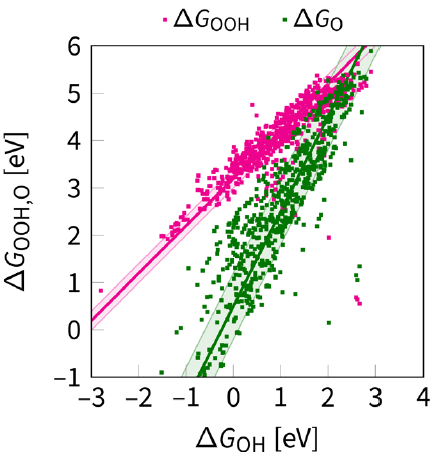

In the figure, from https://doi.org/10.1039/D5CS00597C (Twenty years after: scaling relations in oxygen electrocatalysis and beyond), you see two important scaling relations. Each point represents a catalyst, while the straight-line trends show that the adsorption energies follow approximately linear relationships. These correlations are useful because they allow catalyst performance to be predicted from a small set of descriptors. At the same time, they impose fundamental constraints on catalyst optimization, since improving the binding of one intermediate often affects the others in a linked manner.

### Correlations

Scaling relations describe linear correlations between the adsorption free energies of reaction intermediates. In oxygen electrocatalysis, the adsorption energies of OOH, OH, and O are not independent, but are linked through approximate linear relationships:

$$
\Delta G_{\mathrm{OOH}} \approx \Delta G_{\mathrm{OH}} + 3.2 \pm 0.2 \ \mathrm{eV}
$$

$$
\Delta G_{\mathrm{O}} \approx 2\,\Delta G_{\mathrm{OH}} + 0.5 \pm 0.7 \ \mathrm{eV}
$$

These relationships imply that strengthening or weakening the adsorption of one intermediate will affect the adsorption of the others in a predictable way.

## Calculating the OH–OOH scaling relation

Before computing adsorption energies, we load the UMA machine learning potential and calculate reference energies for H₂ and H₂O. These are needed for the Hess cycle expressions used throughout the notebook.

In [5]:
unit = pretrained_mlip.load_predict_unit('uma-s-1p1.pt')
calc = FAIRChemCalculator(unit, task_name='oc20')

H2 = molecule('H2')
H2.set_cell([10, 10, 10])
H2.center()
H2.pbc = True
H2.calc = calc

opt = BFGS(H2, trajectory='H2.traj', logfile='H2.log')
opt.run(fmax=0.01, steps=53)

H2_ref = H2.get_potential_energy()

H2O = molecule('H2O')
H2O.set_cell([10, 10, 10])
H2O.center()
H2O.pbc = True
H2O.calc = calc

opt = BFGS(H2O, trajectory='H2O.traj', logfile='H2O.log')
opt.run(fmax=0.01, steps=53)

H2O_ref = H2O.get_potential_energy()

print(H2_ref, H2O_ref)

-6.969667282827117 -14.155359539399678


In [6]:
df_scaling = pd.DataFrame(columns=['metal', 'E_O', 'E_OH', 'E_OOH'])

We now compute adsorption energies for O, OH, and OOH on a series of FCC(111) metal surfaces using the UMA potential. For each metal we optimize the clean slab, then sequentially add each adsorbate, re-optimize, and extract the adsorption energy using the standard reference subtraction.

In [7]:
%%time

unit = pretrained_mlip.load_predict_unit('uma-s-1p1.pt')
calc = FAIRChemCalculator(unit, task_name='oc20')

metals = ['Au', 'Ag', 'Cu', 'Ir', 'Pd', 'Pt', 'Rh']

for metal in metals:
  atoms = fcc111(metal, size=(3, 3, 5), vacuum=10.0)
  atoms.translate([0, 0, -4])
  atoms.pbc = True
  atoms.set_constraint(FixAtoms(mask=[atom.index < 3*2*(3 - 1) for atom in atoms]))
  atoms.calc = calc

  opt = BFGS(atoms, trajectory=f'{metal}_slab.traj', logfile=f'{metal}_slab.log')
  opt.run(fmax=0.1, steps=101)
  E_slab = atoms.get_potential_energy()

  add_adsorbate(atoms, Atoms('O', positions=[(0, 0, 0)]), 1.5, 'ontop')

  opt = BFGS(atoms, trajectory=f'{metal}_O.traj', logfile=f'{metal}_O.log')
  opt.run(fmax=0.1, steps=101)
  E_slab_O = atoms.get_potential_energy()

  del atoms[-1:]

  OH = Atoms('OH', positions=[(0, 0, 0), (0.7, 0, 0.7)])
  add_adsorbate(atoms, OH, 1.8, 'ontop')

  opt = BFGS(atoms, trajectory=f'{metal}_OH.traj', logfile=f'{metal}_OH.log')
  opt.run(fmax=0.1, steps=101)
  E_slab_OH = atoms.get_potential_energy()

  del atoms[-2:]

  OOH = Atoms('OOH', positions=[(0, 0, 0), (0.1, 0, 1.5), (0.7, 0, 2.2)])
  add_adsorbate(atoms, OOH, 1.8, 'ontop')

  opt = BFGS(atoms, trajectory=f'{metal}_OOH.traj', logfile=f'{metal}_OOH.log')
  opt.run(fmax=0.1, steps=101)
  E_slab_OOH = atoms.get_potential_energy()

  del atoms[-3:]

  E_O = E_slab_O - E_slab - H2O_ref + H2_ref
  E_OH = E_slab_OH - E_slab - H2O_ref + 0.5*H2_ref
  E_OOH = E_slab_OOH - E_slab - 2*H2O_ref + 1.5*H2_ref

  df_scaling.loc[len(df_scaling)] = [metal, E_O, E_OH, E_OOH]

  print(f'{metal}: E_O={E_O:.3f}, E_OH={E_OH:.3f}, E_OOH={E_OOH:.3f}')

Au: E_O=3.785, E_OH=1.549, E_OOH=4.732
Ag: E_O=3.453, E_OH=1.219, E_OOH=4.342
Cu: E_O=2.603, E_OH=0.817, E_OOH=4.008
Ir: E_O=1.821, E_OH=0.682, E_OOH=3.805
Pd: E_O=2.836, E_OH=1.054, E_OOH=4.131
Pt: E_O=2.751, E_OH=1.035, E_OOH=4.062
Rh: E_O=1.901, E_OH=0.671, E_OOH=3.792
CPU times: user 20min 57s, sys: 2.41 s, total: 20min 59s
Wall time: 20min 18s


In [8]:
df_scaling

,metal,E_O,E_OH,E_OOH
0,Au,3.784508,1.549431,4.731815
1,Ag,3.453154,1.218941,4.341713
2,Cu,2.603333,0.816793,4.007520
3,Ir,1.820912,0.681754,3.804692
4,Pd,2.836236,1.053696,4.131386
5,Pt,2.750837,1.034577,4.061541
6,Rh,1.901486,0.670513,3.792371


In [9]:
backup = df_scaling.copy()
df_scaling = df_scaling[~df_scaling['metal'].isin(['Ni'])]
df_scaling = df_scaling.reset_index(drop=True)

With adsorption energies computed for all seven metals, we fit linear scaling relations between OH and OOH, and between OH and O, using linear regression. The resulting slopes and intercepts can be compared directly against the universal values reported in the literature.

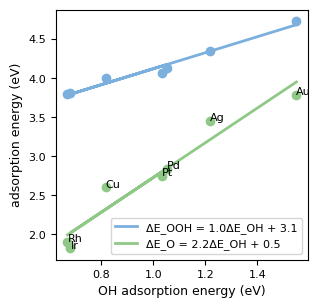

In [10]:
##-Extract ΔE values for OOH and OH-##
E_OOH = df_scaling['E_OOH'].values
E_OH = df_scaling['E_OH'].values
E_O = df_scaling['E_O'].values
metals = df_scaling['metal'].values

##-Perform linear regression-##
slope_OOH, intercept_OOH, r_value_OOH, p_value_OOH, std_err_OOH = linregress(E_OH, E_OOH)
slope_O, intercept_O, r_value_O, p_value_O, std_err_O = linregress(E_OH, E_O)

##-Plot ΔE_OH vs ΔE_OOH with linear fit-##
plt.figure()
plt.scatter(E_OH, E_OOH, color=tol_colors[1])
plt.scatter(E_OH, E_O, color=tol_colors[2])

##-Plot the fitted line-##
plt.plot(E_OH, slope_OOH * E_OH + intercept_OOH, color=tol_colors[1], label=f'ΔE_OOH = {slope_OOH:.1f}ΔE_OH + {intercept_OOH:.1f}')
plt.plot(E_OH, slope_O * E_OH + intercept_O, color=tol_colors[2], label=f'ΔE_O = {slope_O:.1f}ΔE_OH + {intercept_O:.1f}')

##-Annotate points with metal names-##
for i, metal in enumerate(metals):
  plt.annotate(metal, (E_OH[i], E_O[i]), fontsize=8)

plt.xlabel('OH adsorption energy (eV)')
plt.ylabel('adsorption energy (eV)')
plt.legend()
plt.show()

The slopes and intercepts of the scaling relations are not empirical coincidences. They follow from electron counting at the active site and from bond energies that do not depend on the catalyst. Here we derive both α and β from first principles to understand why these relations hold across such a wide range of materials.

## Thermochemical origin of $\alpha$ and $\beta$

A scaling relation can be written as

$$
\Delta G_A = \alpha \Delta G_B + \beta
$$

The slope $\alpha$ follows from electron counting in the active site-adsorbate bond.

For OOH vs OH, both intermediates require one valence electron for the surface-oxygen bond. Therefore,

$$
\alpha \approx 1
$$

For O vs OH, O lacks two electrons to complete the octet, while OH lacks one. Therefore,

$$
\alpha \approx 2
$$

The intercept $\beta$ is the part that remains after the catalyst-dependent surface bonding is removed.

For OOH vs OH, $\beta$ originates from two terms. The first is the reference-state thermochemistry of $\mathrm{H_2}$ and $\mathrm{H_2O}$:

$$
\beta_{\mathrm{ref}} = 2.46 \ \mathrm{eV}
$$

The second is the oxygen-oxygen bond term. It comes from changing the oxygen-oxygen bond from the double bond in $\mathrm{O_2}$ to the single peroxide bond in OOH. This term is estimated from the difference between half of an $\mathrm{O=O}$ bond and one peroxide $\mathrm{O-O}$ bond:

$$
\beta_{\mathrm{O-O}} = 0.40 \text{ to } 0.84 \ \mathrm{eV}
$$

Thus,

$$
\beta = \beta_{\mathrm{ref}} + \beta_{\mathrm{O-O}}
$$

$$
\beta = 2.46 + (0.40 \text{ to } 0.84)
$$

$$
\beta \approx 3.1 \pm 0.2 \ \mathrm{eV}
$$

For O vs OH, $\beta$ originates from the exchange of oxygen single and double bonds between the active site and hydrogen:

$$
2*\mathrm{OH} \rightarrow \mathrm{H_2O} + *\mathrm{O} + *
$$

The formation of $\mathrm{H_2O}$ releases about $0.74 \ \mathrm{eV}$. This energy is used to break the site-oxygen double bond into two site-oxygen single bonds. The latter term is estimated as

$$
1.27 \pm 0.74 \ \mathrm{eV}
$$

Therefore,

$$
\beta = (1.27 \pm 0.74) - 0.74
$$

$$
\beta \approx 0.5 \pm 0.7 \ \mathrm{eV}
$$

## Summary

After running this notebook should know that:

1. Scaling relations are linear correlations between intermediate adsorption energies. Across transition metal surfaces, ΔGOOH ≈ ΔGOH + 3.2 ± 0.2 eV and ΔGO ≈ 2·ΔGOH + 0.5 ± 0.7 eV. These allow the full ORR energy landscape to be estimated from a single descriptor.
2. The slope α follows from electron counting. OOH and OH both form one bond to the surface, so their energies shift together and α ≈ 1. O forms two bonds to the surface compared to OH's one, so its energy shifts twice as fast and α ≈ 2.

3. The intercept β comes from catalyst-independent bond energies. For OOH vs OH, β arises from the H₂/H₂O reference thermochemistry (about 2.46 eV) plus the energy cost of replacing an O=O double bond with an O-O peroxide single bond (about 0.4 to 0.8 eV), giving β ≈ 3.1 ± 0.2 eV. For O vs OH, β arises from the bond rearrangement in 2·OH → H₂O + O* + *, giving β ≈ 0.5 ± 0.7 eV.
4. Scaling relations constrain catalyst optimization. Because adsorption energies of similar intermediates move together, it is not possible to tune ΔGOH independently of ΔGOOH within a single catalyst family. This constraint is the fundamental reason a finite minimum overpotential exists for the ORR on simple metal surfaces.

You should be able to:

1. Compute scaling relation data computationally. Build FCC(111) slabs for multiple metals with ASE, run sequential adsorbate optimizations using UMA (reusing the same slab by deleting and re-adding adsorbates), apply the standard Hess cycle expressions for O, OH, and OOH adsorption energies, and store results in a pandas DataFrame.
2. Fit and interpret linear regressions. Use scipy.stats.linregress to extract slope, intercept, and R² for each scaling relation, overlay the fitted lines on a scatter plot with annotated metal labels, and compare the computed slopes and intercepts against the universal literature values.